# 05 - From PNG with Metadata Presets

Ejemplos de carga de una imagen PNG en `MammographyDicom`, inicializacion con presets/defaults de metadata y actualizacion de metadata tras el procesado.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'api_stable').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from api_stable.mammography import MammographyDicom

In [2]:
PNG_PATH = Path('/home/eloygarcia/Escritorio/Datasets/RSNA_png/train_images/5/640805896.png')
if not PNG_PATH.exists():
    raise FileNotFoundError(f'Actualiza PNG_PATH: {PNG_PATH}')

print('PNG_PATH =', PNG_PATH)

PNG_PATH = /home/eloygarcia/Escritorio/Datasets/RSNA_png/train_images/5/640805896.png


MammographyMetadata(patient=PatientInfo(patient_id=None, age=None, sex=None), vendor=VendorInfo(manufacturer='HOLOGIC, Inc.', model_name='Selenia Dimensions'), acquisition=AcquisitionInfo(kvp=None, exposure=None, exposure_time=None, tube_current=None, compression_force=None), breast=BreastInfo(laterality=None, view=None, breast_implant_present=None), image=ImageInfo(rows=2776, columns=2082, bits_stored=8, pixel_spacing=(0.07, 0.07), photometric_interpretation='MONOCHROME2', presentation_lut_shape='IDENTITY', window_center=153, window_width=38, window_center_width_explanation='AUTO', voi_lut_function='LINEAR'))


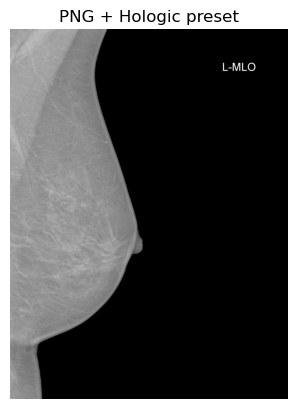

In [3]:
mammo_hologic = MammographyDicom.from_png(
    PNG_PATH,
    metadata_preset='Hologic',
)

print(mammo_hologic.metadata)

plt.imshow(mammo_hologic.image.to_numpy(), cmap='gray')
plt.title('PNG + Hologic preset')
plt.axis('off')
plt.show()

ImageInfo(rows=2776, columns=2082, bits_stored=None, pixel_spacing=(0.07, 0.07), photometric_interpretation='MONOCHROME2', presentation_lut_shape='IDENTITY', window_center=0, window_width=0, window_center_width_explanation='NORMALIZED', voi_lut_function='LINEAR')
['apply_windowing( window_center=127.5, window_width=255, voi_lut_function=LINEAR)', 'normalize']


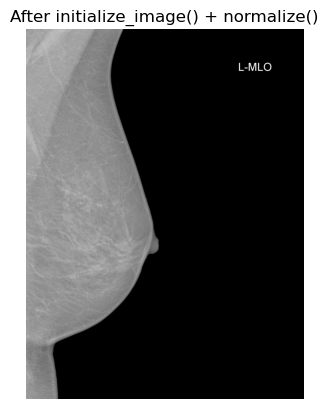

In [4]:
mammo_hologic.initialize_image()
mammo_hologic.normalize()

print(mammo_hologic.metadata.image)
print(mammo_hologic.image.get_history())

plt.imshow(mammo_hologic.image.to_numpy(), cmap='gray')
plt.title('After initialize_image() + normalize()')
plt.axis('off')
plt.show()

In [5]:
mammo_custom = MammographyDicom.from_png(
    PNG_PATH,
    metadata_defaults={
        'vendor': {
            'manufacturer': 'CUSTOM_VENDOR',
            'model_name': 'CUSTOM_MODEL',
        },
        'image': {
            'photometric_interpretation': 'MONOCHROME1',
        },
    },
)

print(mammo_custom.metadata)

MammographyMetadata(patient=PatientInfo(patient_id=None, age=None, sex=None), vendor=VendorInfo(manufacturer='CUSTOM_VENDOR', model_name='CUSTOM_MODEL'), acquisition=AcquisitionInfo(kvp=None, exposure=None, exposure_time=None, tube_current=None, compression_force=None), breast=BreastInfo(laterality=None, view=None, breast_implant_present=None), image=ImageInfo(rows=2776, columns=2082, bits_stored=8, pixel_spacing=None, photometric_interpretation='MONOCHROME1', presentation_lut_shape='IDENTITY', window_center=153, window_width=38, window_center_width_explanation='AUTO', voi_lut_function='LINEAR'))


In [6]:
import os

mammo_override = MammographyDicom.from_png(
    PNG_PATH,
    metadata_preset='GE',
    metadata_overrides={
        'patient':{'patient_id': os.path.basename(PNG_PATH)},
        'breast': {'laterality': 'L', 'view': 'MLO'},
        #'image': {'photometric_interpretation': 'MONOCHROME1'},
    },
)

mammo_override.initialize_image()
print(mammo_override.metadata)

MammographyMetadata(patient=PatientInfo(patient_id='640805896.png', age=None, sex=None), vendor=VendorInfo(manufacturer='GE Healthcare', model_name='Senographe Pristina'), acquisition=AcquisitionInfo(kvp=None, exposure=None, exposure_time=None, tube_current=None, compression_force=None), breast=BreastInfo(laterality='L', view='MLO', breast_implant_present=None), image=ImageInfo(rows=2776, columns=2082, bits_stored=None, pixel_spacing=(0.1, 0.1), photometric_interpretation='MONOCHROME2', presentation_lut_shape='IDENTITY', window_center=153, window_width=38, window_center_width_explanation='APPLIED', voi_lut_function='SIGMOID'))


['apply_windowing( window_center=153, window_width=38, voi_lut_function=SIGMOID)']


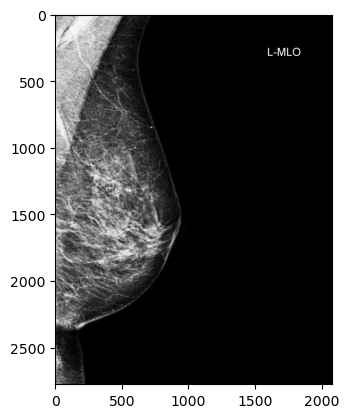

In [7]:
print(mammo_override.image.get_history())

plt.imshow(mammo_override.image.to_numpy(), cmap='gray')
plt.show()